<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-459/2847148778.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period='1y')['Close']
[*********************100%***********************]  4 of 4 completed


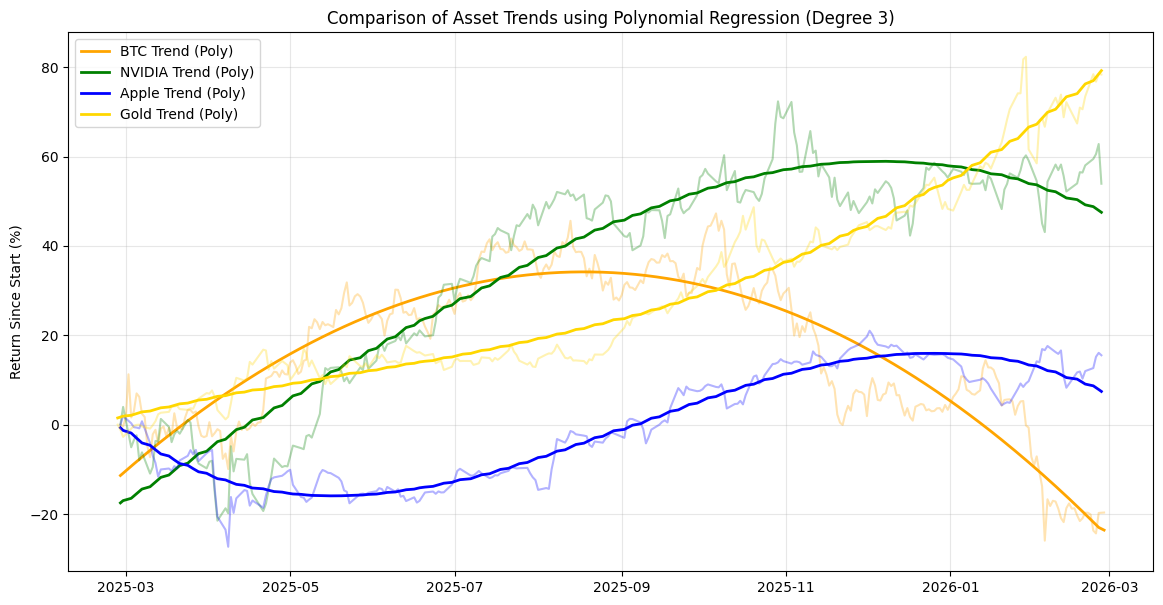

In [4]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

# 1. ดึงข้อมูลย้อนหลัง 1 ปี (จนถึงปัจจุบัน กุมภาพันธ์ 2026)
tickers = {'BTC': 'BTC-USD', 'NVIDIA': 'NVDA', 'Apple': 'AAPL', 'Gold': 'GC=F'}
data = yf.download(list(tickers.values()), period='1y')['Close']

# 2. ปรับข้อมูลให้เป็นอัตราการเติบโต (%) เพื่อให้เปรียบเทียบกันได้ (Normalize)
# เนื่องจากราคา BTC หลักล้าน แต่หุ้นหลักร้อย การเทียบ % จะเห็นภาพชัดกว่า
# แก้ไข: ปรับการ Normalization ให้ใช้ค่าแรกที่ไม่ใช่ NaN ของแต่ละคอลัมน์
data_norm = data.apply(lambda x: (x / x.dropna().iloc[0] - 1) * 100)

# 3. ฟังก์ชันสร้าง Polynomial Regression
def fit_polynomial(y_data, degree=3):
    X = np.arange(len(y_data)).reshape(-1, 1)
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y_data)
    return model.predict(X_poly)

# 4. พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
colors = ['orange', 'green', 'blue', 'gold']

for i, (name, ticker) in enumerate(tickers.items()):
    actual = data_norm[ticker].dropna()
    # ตรวจสอบว่ามีข้อมูลเพียงพอสำหรับการทำ Polynomial Regression หรือไม่
    if len(actual) > 3: # 'degree' is defined in fit_polynomial, use a generic check
        trend = fit_polynomial(actual, degree=3) # ใช้ Degree 3 เพื่อดูความโค้ง S-curve
        plt.plot(actual.index, actual, alpha=0.3, color=colors[i]) # กราฟจริง (จางๆ)
        plt.plot(actual.index, trend, label=f'{name} Trend (Poly)', color=colors[i], linewidth=2)
    else:
        print(f"Warning: Not enough data for {name} to perform Polynomial Regression with degree 3. Skipping trend plot.")
        plt.plot(actual.index, actual, label=f'{name} (Actual)', color=colors[i], linewidth=1)

plt.title('Comparison of Asset Trends using Polynomial Regression (Degree 3)')
plt.ylabel('Return Since Start (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Weighted Least Squares (WLS) Polynomial

[*********************100%***********************]  4 of 4 completed


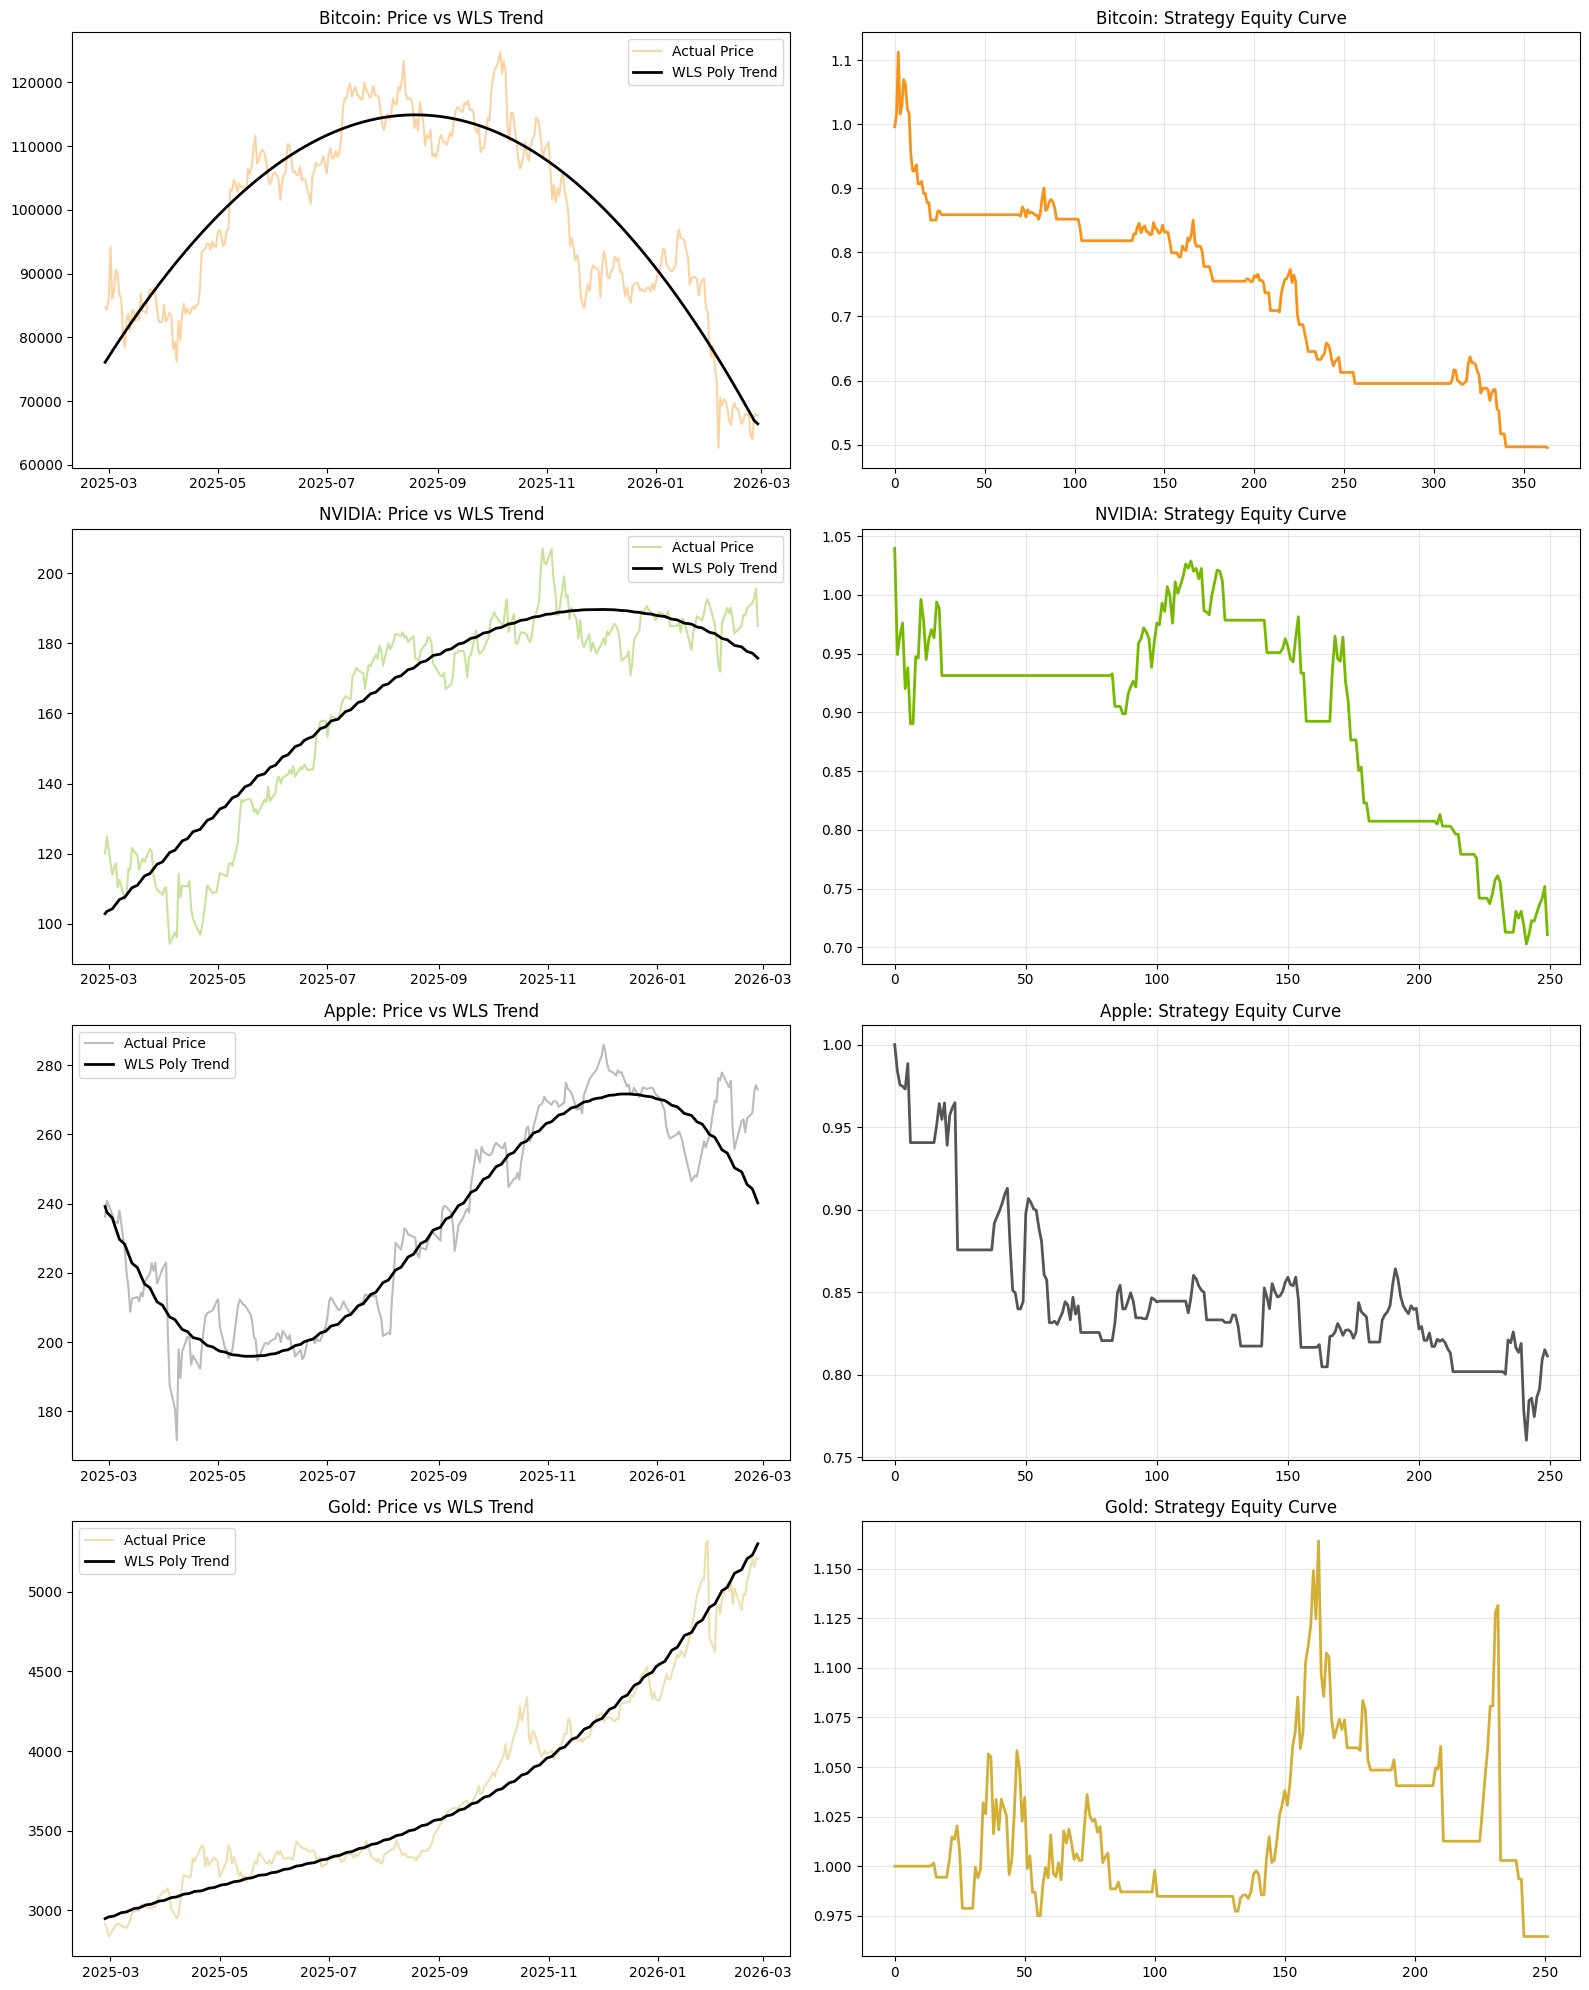

In [16]:


# 1. ดึงข้อมูล 4 สินทรัพย์ (ข้อมูลย้อนหลัง 1 ปี)
tickers = {'Bitcoin': 'BTC-USD', 'NVIDIA': 'NVDA', 'Apple': 'AAPL', 'Gold': 'GC=F'}
# หมายเหตุ: ข้อมูลอัปเดตถึงกุมภาพันธ์ 2026 ราคา BTC ประมาณ $68k, ทองคำ ~$5,160
df = yf.download(list(tickers.values()), period='1y', auto_adjust=True)['Close']

# ฟังก์ชันคำนวณ WLS Polynomial และ Backtest
def analyze_asset(name, ticker_col):
    price = df[ticker_col].dropna()
    returns = price.pct_change()

    # คำนวณ Weights (1 / Variance) - Gauss-Markov Approach
    vol = returns.rolling(window=14).std()
    weights = 1 / (vol**2)
    weights = weights.replace([np.inf, -np.inf], np.nan).fillna(weights.median())

    # สร้าง Polynomial Trend (Degree 3)
    X = np.arange(len(price)).reshape(-1, 1)
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(X)

    model = LinearRegression().fit(X_poly, price, sample_weight=weights.values)
    trend = model.predict(X_poly)

    # Backtest กลยุทธ์
    signal = np.where(price.values > trend, 1, 0)
    strat_ret = (signal[:-1] * returns.values[1:]) # Shift signal
    cum_strat = np.cumprod(1 + np.nan_to_num(strat_ret))

    return price, trend, cum_strat

# 2. Plot กราฟเปรียบเทียบ
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
colors = ['#f7931a', '#76b900', '#555555', '#d4af37']

for i, (name, ticker) in enumerate(tickers.items()):
    price, trend, cum_strat = analyze_asset(name, ticker)

    # กราฟราคาและ Trend
    axes[i, 0].plot(price.index, price, label='Actual Price', color=colors[i], alpha=0.4)
    axes[i, 0].plot(price.index, trend, label='WLS Poly Trend', color='black', linewidth=2)
    axes[i, 0].set_title(f'{name}: Price vs WLS Trend')
    axes[i, 0].legend()

    # กราฟกำไรสะสม (Normalized)
    axes[i, 1].plot(cum_strat, label='Strategy Return', color=colors[i], linewidth=2)
    axes[i, 1].set_title(f'{name}: Strategy Equity Curve')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Correlation & Portfolio Optimization (Feb 2026)

[*********************100%***********************]  4 of 4 completed


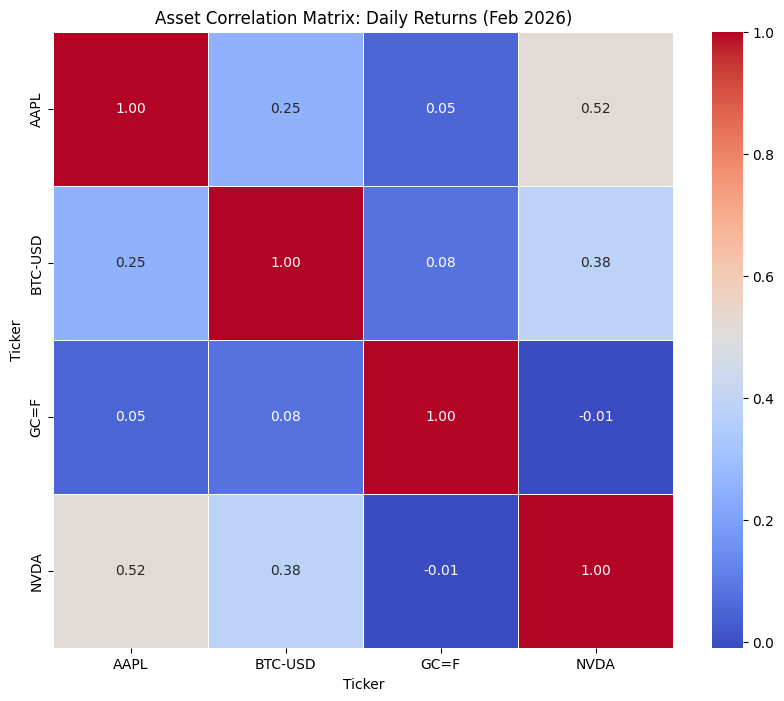

--- สัดส่วนการลงทุนที่เสี่ยงต่ำที่สุด (Minimum Variance) ---
 Asset  Optimal_Weight (%)
   BTC               26.93
NVIDIA               10.00
 Apple               56.64
  Gold                6.43


In [15]:


# 1. ดึงข้อมูล 4 สินทรัพย์ (อัปเดตล่าสุด กุมภาพันธ์ 2026)
tickers = {'BTC': 'BTC-USD', 'NVIDIA': 'NVDA', 'Apple': 'AAPL', 'Gold': 'GC=F'}
df = yf.download(list(tickers.values()), period='1y', auto_adjust=True)['Close']

# 2. คำนวณ Returns (Daily Log Returns) เพื่อความแม่นยำทางสถิติ
data_returns = np.log(df / df.shift(1)).dropna()

# 3. สร้าง Correlation Matrix
corr_matrix = data_returns.corr()

# 4. แสดงผล Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Asset Correlation Matrix: Daily Returns (Feb 2026)')
plt.show()

# 5. ประยุกต์ใช้ Gauss-Markov: หา Minimum Variance Portfolio (MVP)
# เราใช้วิธีหา Weight (w) ที่ทำให้ความแปรปรวนของพอร์ตต่ำที่สุด
cov_matrix = data_returns.cov() * 252 # Annualized Covariance
inv_cov = np.linalg.inv(cov_matrix)
ones = np.ones(len(tickers))

# สูตรการหา Optimal Weights สำหรับความเสี่ยงต่ำที่สุด
weights = inv_cov.dot(ones) / ones.T.dot(inv_cov).dot(ones)
weights_df = pd.DataFrame({'Asset': tickers.keys(), 'Optimal_Weight (%)': weights * 100})

print("--- สัดส่วนการลงทุนที่เสี่ยงต่ำที่สุด (Minimum Variance) ---")
print(weights_df.round(2).to_string(index=False))